In [1]:
import os
import numpy as np
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, LSTM, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
# Set the path to your dataset folder
dataset_folder = 'cell_images'

In [3]:
import cv2

infected_paths = glob(os.path.join(dataset_folder, "Parasitized", "*.png"))
uninfected_paths = glob(os.path.join(dataset_folder, "Uninfected", "*.png"))

image_paths = infected_paths + uninfected_paths
labels = [1]*len(infected_paths) + [0]*len(uninfected_paths)   # 1=Parasitized, 0=Uninfected

X = []
y = []

for img_path, label in zip(image_paths, labels):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (64, 64))
    X.append(img)
    y.append(label)

X = np.array(X, dtype="float32") / 255.0   # normalize
y = np.array(y)

In [4]:
# Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

y_train = to_categorical(y_train)
y_val = to_categorical(y_val)
y_test = to_categorical(y_test)


In [5]:
def image_to_patches(img, patch_size=32):
    patches = []
    for i in range(0, 64, patch_size):
        for j in range(0, 64, patch_size):
            patches.append(img[i:i+patch_size, j:j+patch_size, :])
    return np.array(patches)

def convert_dataset_to_patches(X):
    return np.array([image_to_patches(x) for x in X])

X_train = convert_dataset_to_patches(X_train)
X_val = convert_dataset_to_patches(X_val)
X_test = convert_dataset_to_patches(X_test)

input_shape = (4, 32, 32, 3)
num_classes = y_train.shape[1]

In [6]:
def create_cnn_lstm_model(input_shape, num_classes):
    model = Sequential()
    model.add(TimeDistributed(Conv2D(32, (3,3), activation='relu', padding='same'), input_shape=input_shape))
    model.add(TimeDistributed(MaxPooling2D((2,2))))
    model.add(TimeDistributed(Conv2D(64, (3,3), activation='relu', padding='same')))
    model.add(TimeDistributed(MaxPooling2D((2,2))))
    model.add(TimeDistributed(Flatten()))
    model.add(LSTM(64))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_cnn_lstm_model(input_shape, num_classes)
model.summary()

C:\Users\Panda\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ time_distributed (TimeDistributed)   │ (None, 4, 32, 32, 32)       │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ (None, 4, 16, 16, 32)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_2 (TimeDistributed) │ (None, 4, 16, 16, 64)       │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_3 (TimeDistributed) │ (None, 4, 8, 8, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_4 (TimeDistributed) │ (None, 4, 4096)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │       1,065,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,088,898 (4.15 MB)

 Trainable params: 1,088,898 (4.15 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
#early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
  #  callbacks=[early_stop]
)

Epoch 1/50
621/621 ━━━━━━━━━━━━━━━━━━━━ 133s 214ms/step - accuracy: 0.9616 - loss: 0.1138 - val_accuracy: 0.9554 - val_loss: 0.1416
Epoch 2/50
621/621 ━━━━━━━━━━━━━━━━━━━━ 129s 207ms/step - accuracy: 0.9661 - loss: 0.0991 - val_accuracy: 0.9539 - val_loss: 0.1461
Epoch 3/50
621/621 ━━━━━━━━━━━━━━━━━━━━ 126s 203ms/step - accuracy: 0.9689 - loss: 0.0895 - val_accuracy: 0.9552 - val_loss: 0.1455
Epoch 4/50
621/621 ━━━━━━━━━━━━━━━━━━━━ 144s 206ms/step - accuracy: 0.9718 - loss: 0.0791 - val_accuracy: 0.9459 - val_loss: 0.1741
Epoch 5/50
621/621 ━━━━━━━━━━━━━━━━━━━━ 123s 198ms/step - accuracy: 0.9757 - loss: 0.0645 - val_accuracy: 0.9539 - val_loss: 0.2030
Epoch 6/50
621/621 ━━━━━━━━━━━━━━━━━━━━ 124s 200ms/step - accuracy: 0.9791 - loss: 0.0553 - val_accuracy: 0.9485 - val_loss: 0.2171
Epoch 7/50
621/621 ━━━━━━━━━━━━━━━━━━━━ 125s 202ms/step - accuracy: 0.9825 - loss: 0.0489 - val_accuracy: 0.9496 - val_loss: 0.2149
Epoch 8/50
621/621 ━━━━━━━━━━━━━━━━━━━━ 124s 199ms/step - accuracy: 0.9851 -

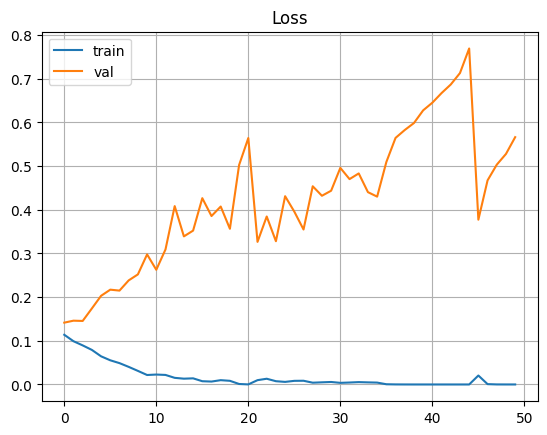

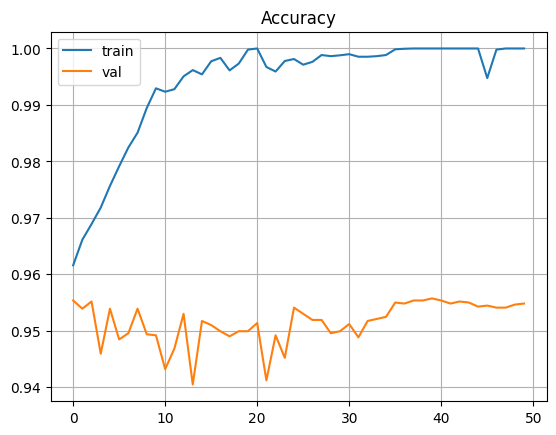

In [12]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.grid()
plt.legend(['train','val'])
plt.show()

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.grid()
plt.title('Accuracy')
plt.legend(['train','val'])
plt.show()

In [13]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes))

cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1111
           1       0.96      0.95      0.95      1094

    accuracy                           0.95      2205
   macro avg       0.95      0.95      0.95      2205
weighted avg       0.95      0.95      0.95      2205

[[1070   41]
 [  60 1034]]


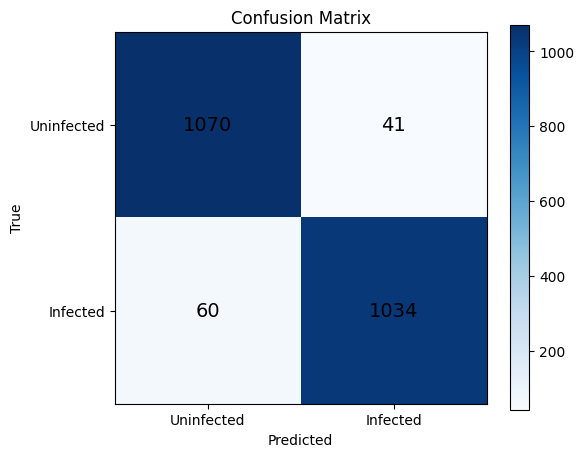

In [14]:
import numpy as np
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

# Add numbers inside the matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=14)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0,1], ["Uninfected", "Infected"])
plt.yticks([0,1], ["Uninfected", "Infected"])
plt.show()


In [16]:
# Evaluate the model on test data
test_loss, test_acc = model.evaluate(X_test, y_test)

69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9542 - loss: 0.5431
